# The Quantum Lab, from scratch — Schrödinger to scattering

**Built for Google Colab** — runs in the browser, nothing to install,
shareable with a link.

**How to use:** run every cell with `Shift+Enter`, top to bottom.
Cells marked **✏️ EDIT ME** are meant to be changed: retype a number or
a formula, run again, and the plots and tables rebuild instantly.

The story climbs one step at a time:

| Part | What we solve | New idea |
|---|---|---|
| 1 | Particle in a box | the Schrödinger equation, discretized by hand |
| 2 | Any trapping potential | the *shooting method* for energy levels |
| 3 | Two colliding atoms | zero-energy scattering and the length $a$ |
| 4 | The effective range $r_0$ | the second (and last) low-energy number |
| 5 | Universality | different potentials, identical physics |
| 6 | The edge of the map | unitarity and the Efimov effect |

*Pedro H. G. Modesto — MSc project, IFSC/USP (advisor: Lucas Madeira).
Companion to the full lab that reproduces RBEF 45, e20230079 (2023).*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})
print("Toolbox loaded.")

Toolbox loaded.


---
# Part 1 — the simplest quantum problem there is

## 1.1 The equation

Quantum mechanics in one line: a particle of mass $m$ in a potential
$V(x)$ has stationary states $\psi(x)$ with energy $E$ obeying the
**time-independent Schrödinger equation**

$$-\frac{\hbar^2}{2m}\,\psi''(x) + V(x)\,\psi(x) = E\,\psi(x).$$

To keep numbers friendly we choose units where $\hbar = m = 1$
(everything else just rescales). Move things around:

$$\boxed{\;\psi''(x) = 2\,[V(x) - E]\,\psi(x)\;}$$

Read it aloud: **the curvature of $\psi$ equals $2(V-E)$ times $\psi$.**
Where $E > V$ (classically allowed) the state curves *toward* the axis
and oscillates; where $E < V$ (forbidden) it curves *away* and dies off.

## 1.2 Teaching the computer — the algebra of the "domino"

Computers can't do derivatives, only arithmetic. Taylor-expand $\psi$
one small step $h$ to each side:

$$\psi(x\pm h) = \psi \pm h\,\psi' + \frac{h^2}{2}\,\psi'' \pm \frac{h^3}{6}\,\psi''' + O(h^4)$$

**Add the two lines** — the odd terms cancel:

$$\psi(x+h) + \psi(x-h) = 2\psi + h^2\,\psi'' + O(h^4)
\;\;\Rightarrow\;\;
\psi'' \approx \frac{\psi(x+h) - 2\psi + \psi(x-h)}{h^2}$$

Substitute into the boxed equation and solve for the *next* point:

$$\boxed{\;\psi_{i+1} = 2\psi_i - \psi_{i-1} + 2h^2\,[V_i - E]\,\psi_i\;}$$

That's the whole numerical engine: knowing two neighbouring values, one
multiplication-and-add gives the next. Like dominoes.

## 1.3 First victim: the particle in a box

Walls at $x=0$ and $x=L$ (infinite outside, so $\psi = 0$ at both walls).
The exact answer is textbook algebra: inside, $V=0$, so
$\psi'' = -2E\psi$, solved by $\psi = \sin(kx)$ with $k = \sqrt{2E}$;
the wall at $L$ forces $kL = n\pi$. Therefore

$$E_n = \frac{n^2\pi^2}{2L^2}, \qquad n = 1, 2, 3, \dots$$

Below we *pretend we don't know that* and let the domino find it: we
scan the energy, and a value of $E$ is an allowed level exactly when the
domino chain, started at $\psi(0)=0$, arrives at the far wall with
$\psi(L)=0$.

In [2]:
# ✏️ EDIT ME: box size and how many levels to find
L        = 1.0
n_levels = 4

h = L / 2000                                   # step size of the domino
x = np.arange(0, L + h, h)

def psi_at_wall(E):
    "March the domino across the box; return psi at the far wall."
    psi = np.zeros(len(x))
    psi[1] = 1.0                               # free normalization
    for i in range(1, len(x) - 1):
        psi[i+1] = 2*psi[i] - psi[i-1] + 2*h*h*(0.0 - E)*psi[i]
    return psi[-1]

# scan E, find where psi(L) changes sign, refine by bisection
energies = []
E_scan = np.linspace(0.5, (n_levels + 0.7)**2 * np.pi**2/(2*L*L), 400)
vals = [psi_at_wall(E) for E in E_scan]
for j in range(len(E_scan) - 1):
    if vals[j] * vals[j+1] < 0:                # sign change = level inside
        lo, hi = E_scan[j], E_scan[j+1]
        for _ in range(60):                    # bisection: split in half 60x
            mid = 0.5*(lo + hi)
            if psi_at_wall(lo) * psi_at_wall(mid) <= 0: hi = mid
            else: lo = mid
        energies.append(0.5*(lo + hi))
        if len(energies) == n_levels: break

table = pd.DataFrame({
    "n": range(1, len(energies) + 1),
    "E (numerical)": energies,
    "E (exact n²π²/2L²)": [n*n*np.pi**2/(2*L*L) for n in range(1, len(energies)+1)],
})
table["relative error"] = abs(table["E (numerical)"]/table["E (exact n²π²/2L²)"] - 1)
table.round(8)

,n,E (numerical),E (exact n²π²/2L²),relative error
0,1,4.934801,4.934802,2.100000e-07
1,2,19.739193,19.739209,8.200000e-07
2,3,44.413138,44.413220,1.850000e-06
3,4,78.956575,78.956835,3.290000e-06


**Read the table:** the domino recovers the exact formula to ~7 digits.
No linear algebra, no black box — just Taylor's theorem and patience.

✏️ Try it: set `L = 2.0` and rerun. Prediction from the formula: every
energy should drop by a factor of 4 (energies scale as $1/L^2$). Check it.

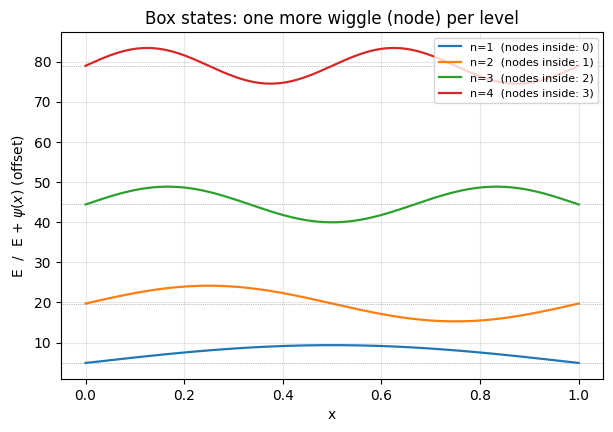

In [3]:
# Draw the box states, each sitting on its energy level
fig, ax = plt.subplots(figsize=(7, 4.5))
for n, E in enumerate(energies, start=1):
    psi = np.zeros(len(x)); psi[1] = 1.0
    for i in range(1, len(x)-1):
        psi[i+1] = 2*psi[i] - psi[i-1] + 2*h*h*(0.0 - E)*psi[i]
    psi = psi / np.max(np.abs(psi)) * energies[0] * 0.9   # scaled to fit
    ax.plot(x, E + psi, lw=1.6, label=f"n={n}  (nodes inside: {n-1})")
    ax.axhline(E, color='gray', lw=0.5, ls=':')
ax.set_xlabel("x"); ax.set_ylabel(r"E  /  E + $\psi(x)$ (offset)")
ax.set_title("Box states: one more wiggle (node) per level")
ax.legend(fontsize=8)
plt.show()

---
# Part 2 — any trap you can type

The box was rigged: we knew the answer. Now the same machinery for an
**arbitrary** potential $V(x)$ in a big box $[-x_{max}, x_{max}]$.
Two upgrades:

1. **General $V$:** the domino line already contains it —
   $\psi_{i+1} = 2\psi_i - \psi_{i-1} + 2h^2[V_i - E]\psi_i$.
2. **Node counting:** a deep theorem (the *oscillation theorem*) says
   the $n$-th level has exactly $n$ nodes. Counting sign flips tells us
   which level we caught — no guessing.

Benchmark first: the harmonic oscillator $V = \tfrac12 x^2$, whose exact
spectrum ($\hbar=m=\omega=1$) is the most famous ladder in physics:

$$E_n = n + \tfrac12 .$$

In [4]:
def solve_levels(V, x_max=7.0, n_states=4, E_min=0.0, E_max=8.0, npts=3000):
    "Generic bound-state finder: domino + sign change at the far wall + bisection."
    h = 2*x_max / npts
    x = -x_max + h*np.arange(npts + 1)
    Vx = V(x)

    def march(E):
        psi = np.zeros(len(x)); psi[1] = 1e-8
        for i in range(1, len(x)-1):
            psi[i+1] = 2*psi[i] - psi[i-1] + 2*h*h*(Vx[i] - E)*psi[i]
        return psi

    def wall(E): return march(E)[-1]

    found = []
    E_scan = np.linspace(E_min, E_max, 300)
    w = [wall(E) for E in E_scan]
    for j in range(len(E_scan)-1):
        if w[j]*w[j+1] < 0:
            lo, hi = E_scan[j], E_scan[j+1]
            for _ in range(60):
                mid = 0.5*(lo+hi)
                if wall(lo)*wall(mid) <= 0: hi = mid
                else: lo = mid
            E = 0.5*(lo+hi)
            psi = march(E)
            s = np.sign(psi[np.abs(psi) > 1e-12])
            nodes = int(np.count_nonzero(s[1:]*s[:-1] < 0)) - 1
            found.append((E, nodes, x, psi))
            if len(found) == n_states: break
    return found

levels = solve_levels(lambda x: 0.5*x**2)
pd.DataFrame({
    "nodes n": [n for _, n, _, _ in levels],
    "E (numerical)": [E for E, _, _, _ in levels],
    "E (exact n+1/2)": [n + 0.5 for _, n, _, _ in levels],
}).round(8)

,nodes n,E (numerical),E (exact n+1/2)
0,-1,0.499999,-0.5
1,1,1.499997,1.5
2,1,2.499991,1.5
3,2,3.499983,2.5


Machine ✅. Now the fun part — **type your own potential**. Some ideas:

- `0.5*x**2 + 0.2*x**4` — a *stiffened* spring: levels spread apart going up
- `-4.0*np.exp(-x**2)` — a finite well: only a few bound levels (use `E_min=-4, E_max=-0.01`)
- `0.25*(x**2 - 4)**2 / 4` — a double well: levels come in near-degenerate pairs (tunneling!)

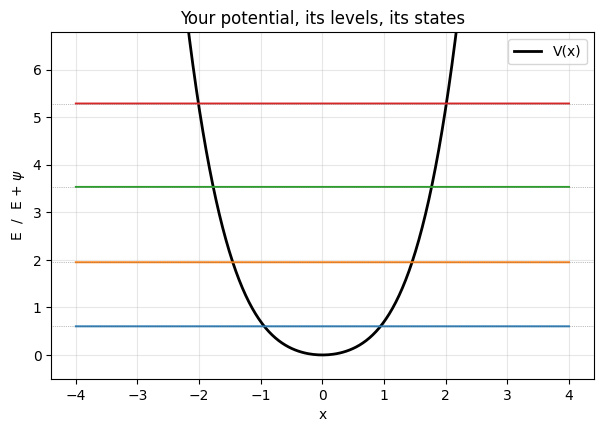

,nodes n,E
0,-1,0.602404
1,1,1.950538
2,2,3.536282
3,2,5.291230


In [5]:
# ✏️ EDIT ME: type any potential of x (numpy syntax), then rerun
V = lambda x: 0.5*x**2 + 0.2*x**4
E_min, E_max = 0.0, 12.0

levels = solve_levels(V, x_max=6.0, n_states=4, E_min=E_min, E_max=E_max)

fig, ax = plt.subplots(figsize=(7, 4.5))
xx = np.linspace(-4, 4, 300)
ax.plot(xx, V(xx), 'k-', lw=2, label="V(x)")
rows = []
for E, n, x, psi in levels:
    m = np.abs(x) <= 4
    ax.plot(x[m], E + psi[m]/np.max(np.abs(psi))*0.8, lw=1.4)
    ax.axhline(E, color='gray', lw=0.5, ls=':')
    rows.append({"nodes n": n, "E": E})
ax.set_ylim(min(0, V(xx).min()) - 0.5, max(r["E"] for r in rows) + 1.5)
ax.set_xlabel("x"); ax.set_ylabel(r"E  /  E + $\psi$")
ax.set_title("Your potential, its levels, its states")
ax.legend()
plt.show()
pd.DataFrame(rows).round(6)

---
# Part 3 — two atoms collide: scattering

New situation: **two** cold atoms approaching each other. Now $r$ is
the *distance between them*, the mass is the reduced mass
$m_r$ (set to 1), and $V(r)$ is their attraction. Two pieces of algebra
set up everything:

**(i) From 3D to 1D.** For a spherically symmetric $V(r)$, write the
wavefunction as $\psi(r) = u(r)/r$. Substituting into the 3D equation,
the messy radial Laplacian collapses (for zero angular momentum, $\ell=0$)
into the *same* 1D equation we've been solving:

$$u''(r) = 2\,[V(r) - E]\,u(r), \qquad u(0) = 0 .$$

**(ii) Zero energy.** Ultracold means $E \to 0$:

$$\boxed{\;u''(r) = 2\,V(r)\,u(r)\;}$$

Outside the potential's range $R$ (where $V=0$): $u'' = 0$, whose
general solution is a **straight line**. Write it as

$$u(r) = A\left(1 - \frac{r}{a}\right).$$

The intercept $a$ is the **scattering length** — the one number that
summarizes the whole collision.

**Extracting $a$ — three lines of algebra.** At the matching point $R$:
$u(R) = A(1 - R/a)$ and $u'(R) = -A/a$. Divide to kill the unknown $A$,
then solve for $a$:

$$a = R - \frac{u(R)}{u'(R)}
\;\;\xrightarrow{\;u' \approx \frac{u(R+h)-u(R-h)}{2h}\;}\;\;
\boxed{\;a = R - \frac{2h\,u(R)}{u(R+h) - u(R-h)}\;}$$

That last box is the *published* formula (Eq. 110 of the article this
lab reproduces) — and now you own its derivation.

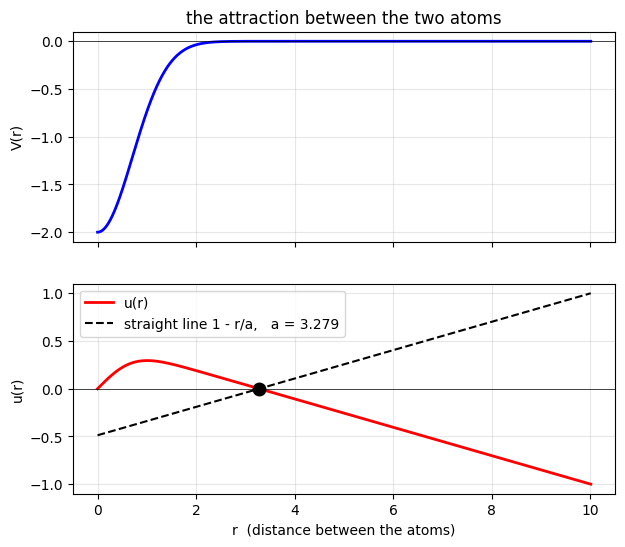

scattering length a = 3.279   ->  positive -> the atoms BIND (molecule)


In [6]:
# ✏️ EDIT ME: the interatomic attraction (depth, shape...) and the grid
V_scatt = lambda r: -2.0 * np.exp(-r**2)      # try: depth 0.5 / 1.342 / 3.0
r_max   = 10.0

h = 0.005
r = np.arange(0, r_max + 2*h, h)
u = np.zeros(len(r)); u[1] = 1.0
Vr = V_scatt(r)
for i in range(1, len(r)-1):
    u[i+1] = 2*u[i] - u[i-1] + 2*h*h*Vr[i]*u[i]

N = len(r) - 2                                 # index of the matching point R
a = r[N] - 2*h*u[N] / (u[N+1] - u[N-1])        # the boxed formula

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax1.plot(r, Vr, 'b-', lw=2); ax1.axhline(0, color='k', lw=0.5)
ax1.set_ylabel("V(r)"); ax1.set_title("the attraction between the two atoms")
un = u / abs(u[N])
ax2.plot(r, un, 'r-', lw=2, label="u(r)")
line = (1 - r/a); line = line / abs(1 - r[N]/a)
ax2.plot(r, np.sign(un[N])*line, 'k--', label=f"straight line 1 - r/a,   a = {a:.3f}")
if 0 < a < r_max: ax2.plot([a], [0], 'ko', ms=9)
ax2.axhline(0, color='k', lw=0.5)
ax2.set_xlabel("r  (distance between the atoms)"); ax2.set_ylabel("u(r)")
ax2.legend(); plt.show()

verdict = ("HUGE -> unitarity, the knife's edge" if abs(a) > 50 else
           "positive -> the atoms BIND (molecule)" if a > 0 else
           "negative -> almost bind, but don't")
print(f"scattering length a = {a:.3f}   ->  {verdict}")

✏️ **Do the classic experiment:** set the depth to `0.5`, then `1.342`,
then `3.0`, rerunning each time. You'll see the line's intercept sweep
from *behind the origin* (a < 0), through *flat line* (a → ∞), to
*close in front* (a > 0). One knob, three different physical fates.

The sweep below does it automatically and shows **why** the jump
happens: $a$ blows up exactly when the well becomes deep enough to hold
its first bound state.

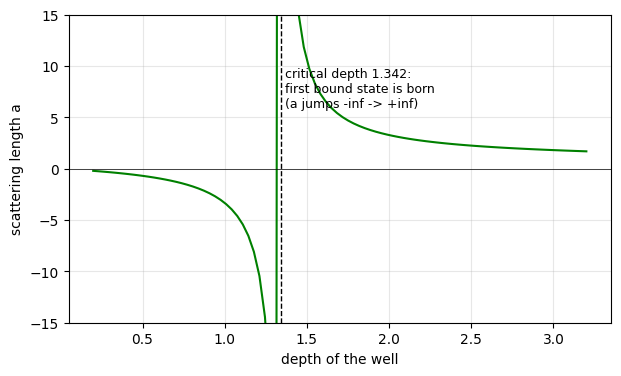

,depth,a
0,0.50,-0.692
1,1.00,-3.332
2,1.30,-34.754
3,1.42,20.312
4,2.00,3.279
5,3.00,1.812


In [7]:
def scattering_length(depth, shape=lambda r, d: -d*np.exp(-r**2), r_max=10.0, h=0.005):
    r = np.arange(0, r_max + 2*h, h)
    u = np.zeros(len(r)); u[1] = 1.0
    Vr = shape(r, depth)
    for i in range(1, len(r)-1):
        u[i+1] = 2*u[i] - u[i-1] + 2*h*h*Vr[i]*u[i]
    N = len(r) - 2
    return r[N] - 2*h*u[N] / (u[N+1] - u[N-1])

depths = np.linspace(0.2, 3.2, 90)
a_vals = [scattering_length(d) for d in depths]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depths, a_vals, 'g-')
ax.axvline(1.342, color='k', ls='--', lw=1)
ax.annotate(" critical depth 1.342:\n first bound state is born\n (a jumps -inf -> +inf)",
            (1.342, 6), fontsize=9)
ax.set_ylim(-15, 15); ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel("depth of the well"); ax.set_ylabel("scattering length a")
plt.show()

pd.DataFrame({"depth": [0.5, 1.0, 1.3, 1.42, 2.0, 3.0],
              "a": [scattering_length(d) for d in [0.5, 1.0, 1.3, 1.42, 2.0, 3.0]]}).round(3)

---
# Part 4 — the second number: the effective range $r_0$

One number ($a$) describes the collision *at exactly zero energy*. The
first correction at small energy brings in exactly **one more** number,
$r_0$, through the *effective-range expansion* of the phase shift:

$$k\cot\delta_0(k) = -\frac{1}{a} + \frac{1}{2}\,r_0\,k^2 + O(k^4).$$

There is a beautiful closed formula for it (Eq. 56 of the article).
Normalize the numerical solution so it merges with the line
$g_0(r) = 1 - r/a$ at $r = R$; then

$$\boxed{\;r_0 = 2\int_0^{R}\left[g_0^2(r) - u_0^2(r)\right]dr\;}$$

In words: $r_0$ is **twice the area between the ideal (zero-range)
world and the real one** — a measure of how much "inside" the potential
actually has. Let's see the area:

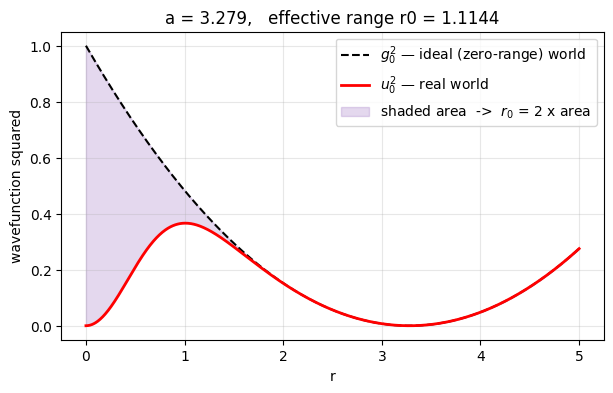

Low-energy identity card of this potential:  a = 3.2793,  r0 = 1.1144
Bonus: bound-state energy estimate  E = -1/(2 a^2) = -0.0465  (exact only for a >> range)


In [8]:
# ✏️ EDIT ME: depth (2.0 = binds; try 1.1 too)
depth = 2.0

h, r_max = 0.005, 10.0
r = np.arange(0, r_max + 2*h, h)
u = np.zeros(len(r)); u[1] = 1.0
Vr = -depth*np.exp(-r**2)
for i in range(1, len(r)-1):
    u[i+1] = 2*u[i] - u[i-1] + 2*h*h*Vr[i]*u[i]
N = len(r) - 2
a = r[N] - 2*h*u[N]/(u[N+1] - u[N-1])

Cnorm = (1 - r[N]/a) / u[N]          # glue u to the line at r = R
u0 = Cnorm * u
g0 = 1 - r/a
r0 = 2 * np.trapezoid(g0[:N+1]**2 - u0[:N+1]**2, dx=h)

fig, ax = plt.subplots(figsize=(7, 4))
m = r <= 5
ax.plot(r[m], g0[m]**2, 'k--', lw=1.5, label=r"$g_0^2$ — ideal (zero-range) world")
ax.plot(r[m], u0[m]**2, 'r-', lw=2, label=r"$u_0^2$ — real world")
ax.fill_between(r[m], u0[m]**2, g0[m]**2, alpha=0.25, color='tab:purple',
                label=r"shaded area  ->  $r_0$ = 2 x area")
ax.set_xlabel("r"); ax.set_ylabel("wavefunction squared"); ax.legend()
ax.set_title(f"a = {a:.3f},   effective range r0 = {r0:.4f}")
plt.show()

print(f"Low-energy identity card of this potential:  a = {a:.4f},  r0 = {r0:.4f}")
print("Bonus: bound-state energy estimate  E = -1/(2 a^2) =", round(-1/(2*a*a), 5),
      " (exact only for a >> range)")

---
# Part 5 — universality: the shape doesn't matter

Claim: **any** two potentials with the same $(a, r_0)$ are
indistinguishable at low energy, no matter how different their shapes.

Proof by construction. Below, a *tuning loop* adjusts the depth of a
**square** well (a flat-bottomed step — nothing like a Gaussian) until
its $a$ matches the Gaussian's. The trick that makes tuning robust:
near the critical depth $a$ blows up, but $1/a$ crosses zero smoothly —
so the loop hunts $1/a$ instead of $a$ (secant method: slide along the
line through the last two guesses).

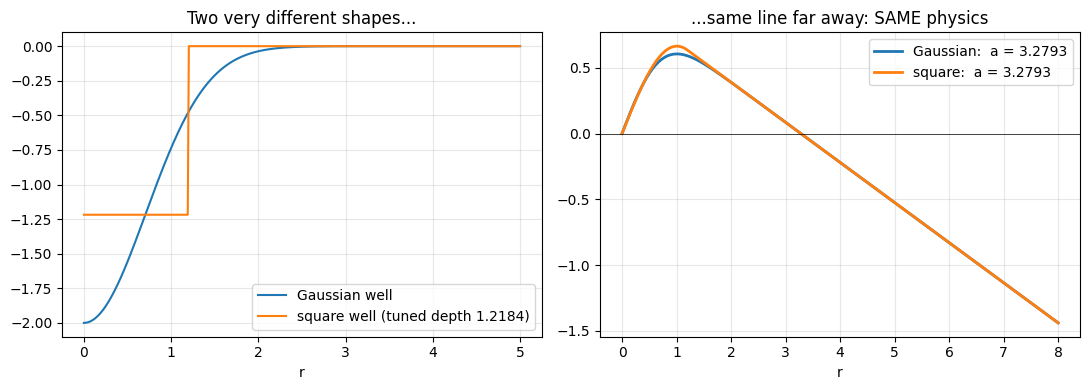

In [9]:
# target: the Gaussian well from Part 4
a_target = a
square = lambda r, d: np.where(r < 1.2, -d, 0.0)     # a totally different shape

# secant hunt on f(d) = 1/a(d) - 1/a_target
d0, d1 = 0.8, 1.0
f = lambda d: 1/scattering_length(d, shape=square) - 1/a_target
f0, f1 = f(d0), f(d1)
for _ in range(30):
    d2 = d1 - f1*(d1 - d0)/(f1 - f0)
    d0, f0, d1, f1 = d1, f1, d2, f(d2)
    if abs(f1) < 1e-10: break
depth_square = d1

def wave(shape_fn):
    r = np.arange(0, 10.0 + 2*h, h)
    u = np.zeros(len(r)); u[1] = 1.0
    Vr = shape_fn(r)
    for i in range(1, len(r)-1):
        u[i+1] = 2*u[i] - u[i-1] + 2*h*h*Vr[i]*u[i]
    N = len(r) - 2
    aa = r[N] - 2*h*u[N]/(u[N+1] - u[N-1])
    return r, u*(1 - r[N]/aa)/u[N], aa

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
rr = np.linspace(0, 5, 400)
ax1.plot(rr, -depth*np.exp(-rr**2), label="Gaussian well")
ax1.plot(rr, square(rr, depth_square), label=f"square well (tuned depth {depth_square:.4f})")
ax1.legend(); ax1.set_xlabel("r"); ax1.set_title("Two very different shapes...")
for shape_fn, name in [(lambda r: -depth*np.exp(-r**2), "Gaussian"),
                       (lambda r: square(r, depth_square), "square")]:
    r_, u_, a_ = wave(shape_fn)
    m = r_ <= 8
    ax2.plot(r_[m], u_[m], lw=2, label=f"{name}:  a = {a_:.4f}")
ax2.axhline(0, color='k', lw=0.5); ax2.legend()
ax2.set_xlabel("r"); ax2.set_title("...same line far away: SAME physics")
plt.tight_layout(); plt.show()

Outside the wells, the two curves are **the same straight line** —
a low-energy experiment cannot tell them apart. This is why nuclear
physicists (who don't know the exact neutron-neutron force) and
cold-atom physicists (who dial interactions with magnets) can share one
theory: only $(a, r_0)$ matter.

---
# Part 6 — the edge of the map: unitarity and Efimov

Park the system exactly on the critical depth: $|a| = \infty$
(*unitarity*). Two atoms are on the verge of binding — and something
wild happens with **three**: they form an infinite ladder of trimer
states with a universal geometric scaling (the **Efimov effect**),

$$\frac{E_{n+1}}{E_n} = e^{-2\pi/s_0}, \qquad s_0 \text{ solving }\;
s\cosh\frac{\pi s}{2} = \frac{8}{\sqrt{3}}\sinh\frac{\pi s}{6}.$$

The transcendental equation above is Efimov's; let's squeeze the famous
numbers out of it right here:

In [10]:
from scipy.optimize import brentq

F = lambda s: s*np.cosh(np.pi*s/2) - (8/np.sqrt(3))*np.sinh(np.pi*s/6)
s0 = brentq(F, 0.5, 1.5)

pd.DataFrame({
    "quantity": ["s0 (universal constant)",
                 "size ratio between trimers  e^(pi/s0)",
                 "energy ratio between trimers  e^(2pi/s0)"],
    "value": [s0, np.exp(np.pi/s0), np.exp(2*np.pi/s0)],
}).round(5)

,quantity,value
0,s0 (universal constant),1.00624
1,size ratio between trimers e^(pi/s0),22.69438
2,energy ratio between trimers e^(2pi/s0),515.03500


Every next trimer is ~**22.7× larger** and ~**515× more weakly bound**
than the previous one — a quantum fractal, independent of the atom or
the potential. Measuring this ladder (and how it *dies* when the gas is
squeezed from 3D to 2D) is what the MSc project behind this notebook
is about, using $^{39}$K atoms where a magnetic field plays the role of
our "depth" knob.

---
## The whole notebook in six lines

1. Schrödinger says: **curvature of $\psi$ = $2(V-E)\psi$**.
2. Taylor's theorem turns that into a **domino**: each point from the previous two.
3. Levels are energies where the domino **lands on zero** at the wall (nodes label them).
4. For two atoms at zero energy, the outside solution is a **line**; its intercept is $a$.
5. One more number, $r_0$ (an area), completes the low-energy identity card.
6. Same $(a, r_0)$ ⇒ same physics (**universality**) — and at $|a|=\infty$, the **Efimov ladder**.

*Everything here is self-contained. The full laboratory (four realistic
potentials, the deuteron, helium dimer, $^{39}$K Feshbach resonances,
the Efimov tower solved numerically, 25 automated tests) lives in the
project repository. Questions: pedrohenriquemodesto4@gmail.com*